## Results analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

Aggregate the results.

In [2]:
def translate_dataset(dataset):
    if dataset == "cifar10":
        return "CIFAR10"
    elif dataset == "mnist":
        return "MNIST"
    elif dataset == "fashion-mnist":
        return "FashionMNIST"
    raise NameError(f"Unsupported dataset: {dataset}")

def translate_method(method):
    if method == "selective-fd":
        return "Selective-FD"
    elif method == "fed-md":
        return "FedMD"
    elif method == "weighted-fd":
        return "Weighted-FD"
    else:
        raise NameError(f"Unsupported method: {method}")
    
    
RESULTS_PATH = os.path.join("..", "ignore", "outputs", "clients-number")

aggregated_data = []
clients_numbers = set()

for dirname in os.listdir(RESULTS_PATH):
    tokens = dirname.split('_')

    algorithm = translate_method(tokens[0])
    dataset = translate_dataset(tokens[1])
    dataset_type = tokens[-3]
    seed = tokens[-2]
    clients_number = int(tokens[-1])
    clients_numbers.add(clients_number)
    for client_idx in range(clients_number):
        client_log = os.path.join(RESULTS_PATH, dirname, 'logs', f'client-{client_idx}.csv')
        client_log = pd.read_csv(client_log)

        # add more fields
        client_log["client"] = np.repeat(client_idx, len(client_log))
        client_log["algorithm"] = np.repeat(algorithm, len(client_log))
        client_log["dataset"] = np.repeat(dataset, len(client_log))
        client_log["dataset_type"] = np.repeat(dataset_type, len(client_log))
        client_log["seed"] = np.repeat(seed, len(client_log))
        client_log["clients_number"] = np.repeat(clients_number, len(client_log))

        aggregated_data.append(client_log)

df = pd.concat(aggregated_data, axis=0).reset_index(drop=True)
df.to_csv(os.path.join("..", "ignore", "aggregated_results.csv"), index=False)
df.head()

,round,mode,accuracy,precision,recall,f1,client,algorithm,dataset,dataset_type,seed,clients_number
0,0,valid,0.6460,0.656595,0.6460,0.642556,0,FedMD,CIFAR10,wni,83,4
1,0,test,0.6536,0.660835,0.6536,0.650251,0,FedMD,CIFAR10,wni,83,4
2,1,valid,0.6960,0.696790,0.6960,0.693473,0,FedMD,CIFAR10,wni,83,4
3,1,test,0.6923,0.693390,0.6923,0.689564,0,FedMD,CIFAR10,wni,83,4
4,2,valid,0.6950,0.705181,0.6950,0.695669,0,FedMD,CIFAR10,wni,83,4


Compare the accuracy:

In [27]:
table_data = []

for dataset_type in df.dataset_type.unique():
    
    current_df = df[df.dataset_type == dataset_type]
    current_df_groups = current_df.groupby(["algorithm", "dataset", "clients_number"])
    
    for group_key in current_df_groups.groups:
        group = current_df_groups.get_group(group_key)
        
        accuracies = []
        
        group_valid = group[ group["mode"] == "valid" ]
        for seed in group_valid.seed.unique():
        
            # # group by rounds, average clients F1 scores per round
            # seed_df = group_valid[ group_valid.seed == seed ] \
            #     .groupby(["round"]).f1.mean().reset_index()
        
            # # select the round with the highest validation F1 score
            # best_valid_round = seed_df[ seed_df.f1 == seed_df.f1.max() ] \
            #     .iloc[0]["round"].astype(int)
            
            # select the client accuracies at the given seed and round
            # and average across the clients to get the seed's best accuracy
            best_test_acc = group[ (group["mode"]  == "test")  & \
                                   (group["seed"]  == seed)    & \
                                   (group["round"] == group["round"].max()) ].accuracy.mean()

            if np.isnan(best_test_acc):
                continue


            accuracies.append(best_test_acc)
        
        accuracies = np.array(accuracies)
        #print(accuracies)

        algorithm, dataset, clients_number = group_key
        
        table_data.append({
            'algorithm': algorithm,
            'dataset': dataset,
            "clients_number": clients_number,
            'dataset_type': dataset_type,
            'accuracy': (np.mean(accuracies) * 100), 
            'std_accuracy': (np.std(accuracies) * 100),
            'accuracies': ', '.join([ str(round(a, 3)) for a in accuracies ])
        })
    
scores = pd.DataFrame(table_data)


scores['score'] = scores.groupby(['dataset_type', 'dataset', "clients_number"])['accuracy'].rank(ascending=False)
scores.sort_values(["dataset", "dataset_type",  "clients_number", "accuracy"], ascending=True, inplace=True)
scores


,algorithm,dataset,clients_number,dataset_type,accuracy,std_accuracy,accuracies,score
88,Weighted-FD,CIFAR10,2,hni,25.926000,9.267514,"0.239, 0.383, 0.16, 0.35, 0.164",3.0
72,FedMD,CIFAR10,2,hni,29.373000,2.452720,"0.302, 0.254, 0.33, 0.287, 0.296",2.0
84,Selective-FD,CIFAR10,2,hni,40.701000,2.211702,"0.416, 0.42, 0.413, 0.363, 0.423",1.0
73,FedMD,CIFAR10,4,hni,17.940500,5.990455,"0.1, 0.269, 0.225, 0.145, 0.158",3.0
85,Selective-FD,CIFAR10,4,hni,26.023500,8.221421,"0.307, 0.122, 0.24, 0.261, 0.371",2.0
...,...,...,...,...,...,...,...,...
10,FedMD,MNIST,6,wni,96.485333,0.059874,"0.965, 0.964, 0.966, 0.965, 0.965",2.0
34,Weighted-FD,MNIST,6,wni,98.282000,0.124866,"0.983, 0.984, 0.983, 0.98, 0.983",1.0
23,Selective-FD,MNIST,8,wni,96.358500,0.073256,"0.964, 0.964, 0.962, 0.964, 0.964",3.0
11,FedMD,MNIST,8,wni,96.504250,0.072239,"0.965, 0.965, 0.964, 0.965, 0.966",2.0


In [28]:
import numpy as np

def generate_accuracy_table(df, clients_number: int):
    # Define the dataset types and their corresponding labels
    dataset_types = {
        'iid': 'IID',
        'wni': 'WNI',
        'hni': 'SNI',
    }
    
    # Initialize the LaTeX table string
    latex_table = r"""
\begin{table*}[ht]
    \centering
    \renewcommand{\arraystretch}{1.6} % Uniform row height
    \setlength{\tabcolsep}{12pt}      % Uniform column spacing
    \small                            % Uniform font size

    \begin{tabular}{c|l|ccc}
        \hline
        & \textbf{Method} & \textbf{MNIST} & \textbf{Fashion MNIST} & \textbf{CIFAR-10}\\ 
        \hline
"""
    citations = {
        'FedMD':        '~\cite{fedmd}', 
        'Selective-FD': '~\cite{selective_fd}', 
        'Weighted-FD':  ' (Proposed)',
    }
    
    
    # Group the dataframe by dataset_type and iterate over each group
    for dataset_type, dataset_type_str in dataset_types.items():
        group = df[ df.dataset_type == dataset_type ]
        group = group[group["clients_number"] == clients_number]

        bold_dataset_type_str = f"\\textbf{{{dataset_type_str}}}"
        latex_table += f"        \\multirow{{3}}{{*}}{{\\rotatebox[origin=c]{{90}}{{{bold_dataset_type_str}}}}}\n"
        
        # Iterate over each algorithm in the group
        for algorithm, citation in citations.items():
            latex_table += f"        & {algorithm.replace('-', ' ')}{citation}"
            
            # Iterate over each dataset and calculate the mean and std deviation of accuracies
            for dataset in  ["MNIST", "FashionMNIST", "CIFAR10"]:
                # accuracies = group[(group['algorithm'] == algorithm) & (group['dataset'] == dataset)]['accuracies']
                # if not accuracies.empty:
                #     accuracies = list(map(float, accuracies.iloc[0].split(', ')))
                #     mean_accuracy = np.mean(accuracies) * 100
                #     std_accuracy = np.std(accuracies) * 100
                #     latex_table += f" & {mean_accuracy:.2f} $\\pm$ {std_accuracy:.2f}"
                # else:
                #     latex_table += " & -"
                
                accuracy = group[(group['algorithm'] == algorithm) & (group['dataset'] == dataset)]['accuracy']
                std_accuracy = group[(group['algorithm'] == algorithm) & (group['dataset'] == dataset)]['std_accuracy']
                score = group[(group['algorithm'] == algorithm) & (group['dataset'] == dataset)]['score']
                
                if accuracy is not None and len(accuracy) > 0:
                    score = int(score.iloc[0])
                    if score == 1:
                        latex_table += f" & \\textbf{{{accuracy.iloc[0]:.2f} $\\pm$ {std_accuracy.iloc[0]:.2f}}}"
                    elif score == 2:
                        latex_table += f" & \\underline{{{accuracy.iloc[0]:.2f} $\\pm$ {std_accuracy.iloc[0]:.2f}}}"
                    else:
                        latex_table += f" & {accuracy.iloc[0]:.2f} $\\pm$ {std_accuracy.iloc[0]:.2f}"
                    
                else:
                    latex_table += " & - "
            latex_table += " \\\\\n"
        
        latex_table += "        \\hline\n"
    
    # Close the LaTeX table string
    latex_table += fr"""
    \end{{tabular}}
    \caption{{Experiments evaluating a {clients_number} clients. Bold values highlight the best performance, while underlined values indicate the second-best. In the non-\acrshort{{iid}} settings, which are the focus of our study, the Weighted-FD method consistently outperforms baseline methods on both the MNIST and FashionMNIST datasets.}}
    \label{{tab:test_results_{clients_number}_clients}}
\end{{table*}}
"""

    
    return latex_table

for clients_number in sorted(clients_numbers):
    
    # Generate the LaTeX table
    latex_table = generate_accuracy_table(scores, clients_number)
    #print(latex_table)

    # Save the LaTeX table to a .tex file
    with open(os.path.join("..", "ignore", f'accuracy_table_{clients_number}_clients.tex'), 'w') as f:
        f.write(latex_table)

print("LaTeX table saved")



LaTeX table saved


Plot the convergence

In [41]:
# def plot_convergence_ax(plot_df, range_builder, ax):
#     #_, ax = plt.subplots(ncols=3, figsize=(15, 4))

#     for i, (dataset_type, dataset_type_label)in enumerate(zip(['iid', 'wni', 'hni'], ["IID", "WNI", "SNI"] )):
#         ax[i].set_title(dataset_type_label, weight="bold")
#         _range = range_builder(dataset_type)
#        # _range = [0.6, 0.8] if dataset_type != 'hni' else [0., 0.8]
#        # _range = [0.94, 1.00] if dataset_type != 'hni' else [0., 1.00]
#         ax[i].set_ylim(_range) 
        
#         curr_df = plot_df[plot_df.dataset_type == dataset_type]
#         curr_df = curr_df[ curr_df['round'] == curr_df['round'].max() ]

#         sns.lineplot(data=curr_df, 
#                     x="clients_number", 
#                     y="accuracy", 
#                     hue="algorithm",
#                     ax=ax[i], 
#                     palette="twilight")
        
def plot_convergence(plot_df, range_builder):
    _, ax = plt.subplots(ncols=3, figsize=(15, 4))

    for i, (dataset_type, dataset_type_label)in enumerate(zip(['iid', 'wni', 'hni'], ["IID", "WNI", "SNI"] )):
        ax[i].set_title(dataset_type_label, weight="bold")
        _range = range_builder(dataset_type)
       # _range = [0.6, 0.8] if dataset_type != 'hni' else [0., 0.8]
       # _range = [0.94, 1.00] if dataset_type != 'hni' else [0., 1.00]
        ax[i].set_ylim(_range) 
        
        curr_df = plot_df[plot_df.dataset_type == dataset_type]
        curr_df = curr_df[ curr_df['round'] == curr_df['round'].max() ]
        sns.lineplot(data=curr_df, 
                    x="clients_number", 
                    y="accuracy", 
                    hue="algorithm",
                    ax=ax[i], 
                    palette="twilight")

    plt.show()


        


Plot MNIST convergence

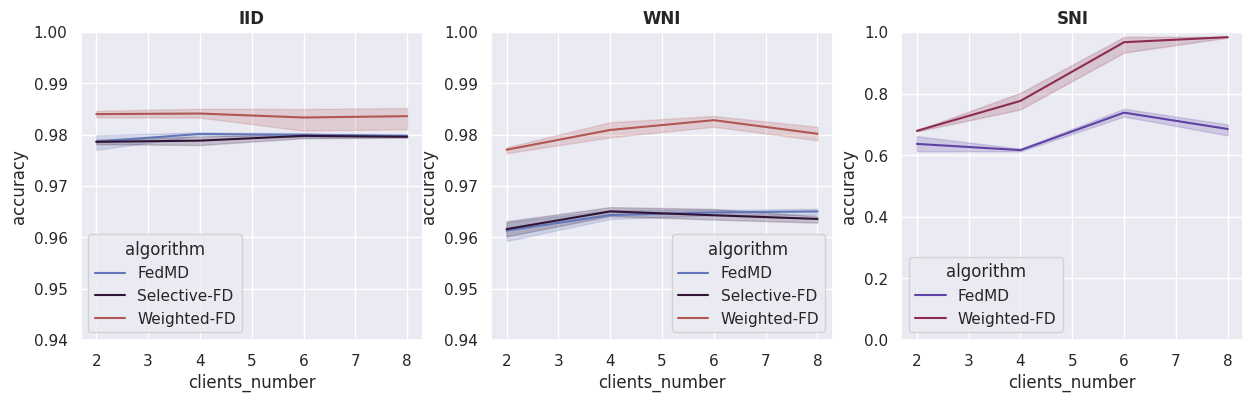

In [42]:
mnist_plot_df = df[ (df["mode"] == "test") & (df["dataset"] == "MNIST") ]  \
            .groupby(["round", "algorithm", "dataset_type", "seed", "clients_number"]) \
            .accuracy.mean().reset_index()
    
plot_convergence(mnist_plot_df, lambda dataset_type : [0.94, 1.00] if dataset_type != 'hni' else [0., 1.00])

Plot FashionMNIST convergence

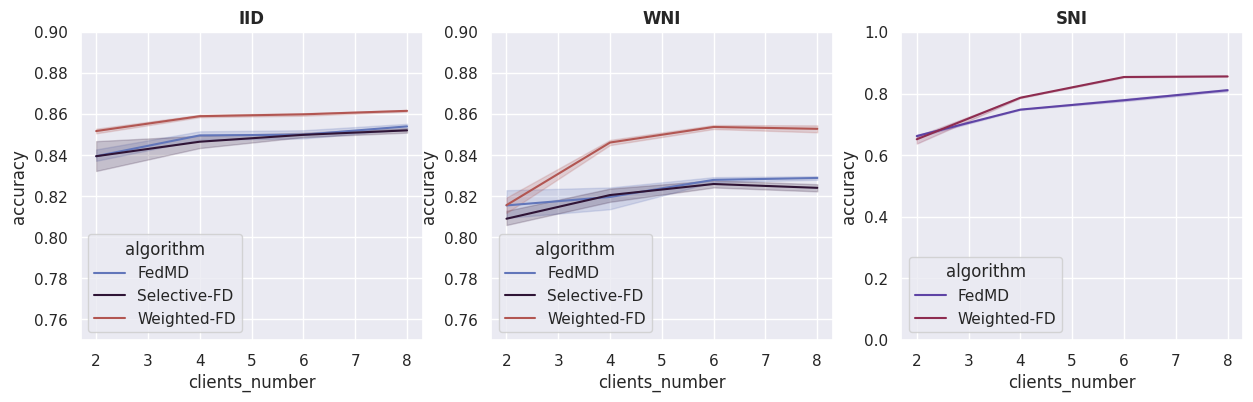

In [43]:
fashion_plot_df = df[ (df["mode"] == "test") & (df["dataset"] == "FashionMNIST") ]  \
            .groupby(["round", "algorithm", "dataset_type", "seed", "clients_number"]) \
            .accuracy.mean().reset_index()
            
plot_convergence(fashion_plot_df, lambda dataset_type : [0.75, 0.90] if dataset_type != 'hni' else [0., 1.00])

Plot CIFAR10 convergence

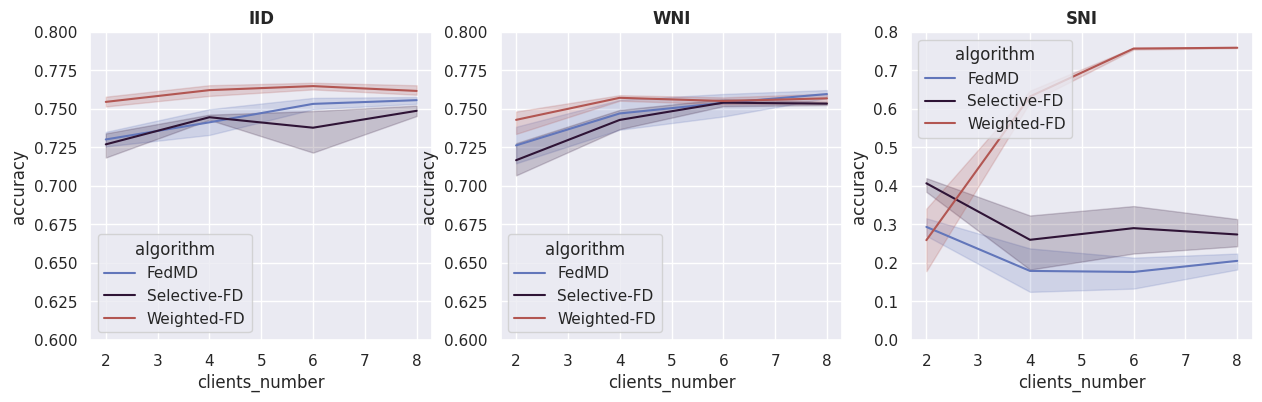

In [44]:
cifar10_plot_df = df[ (df["mode"] == "test") & (df["dataset"] == "CIFAR10") ]  \
            .groupby(["round", "algorithm", "dataset_type", "seed", "clients_number"]) \
            .accuracy.mean().reset_index()

plot_convergence(cifar10_plot_df, lambda dataset_type : [0.6, 0.8] if dataset_type != 'hni' else [0., 0.8])

Table figure

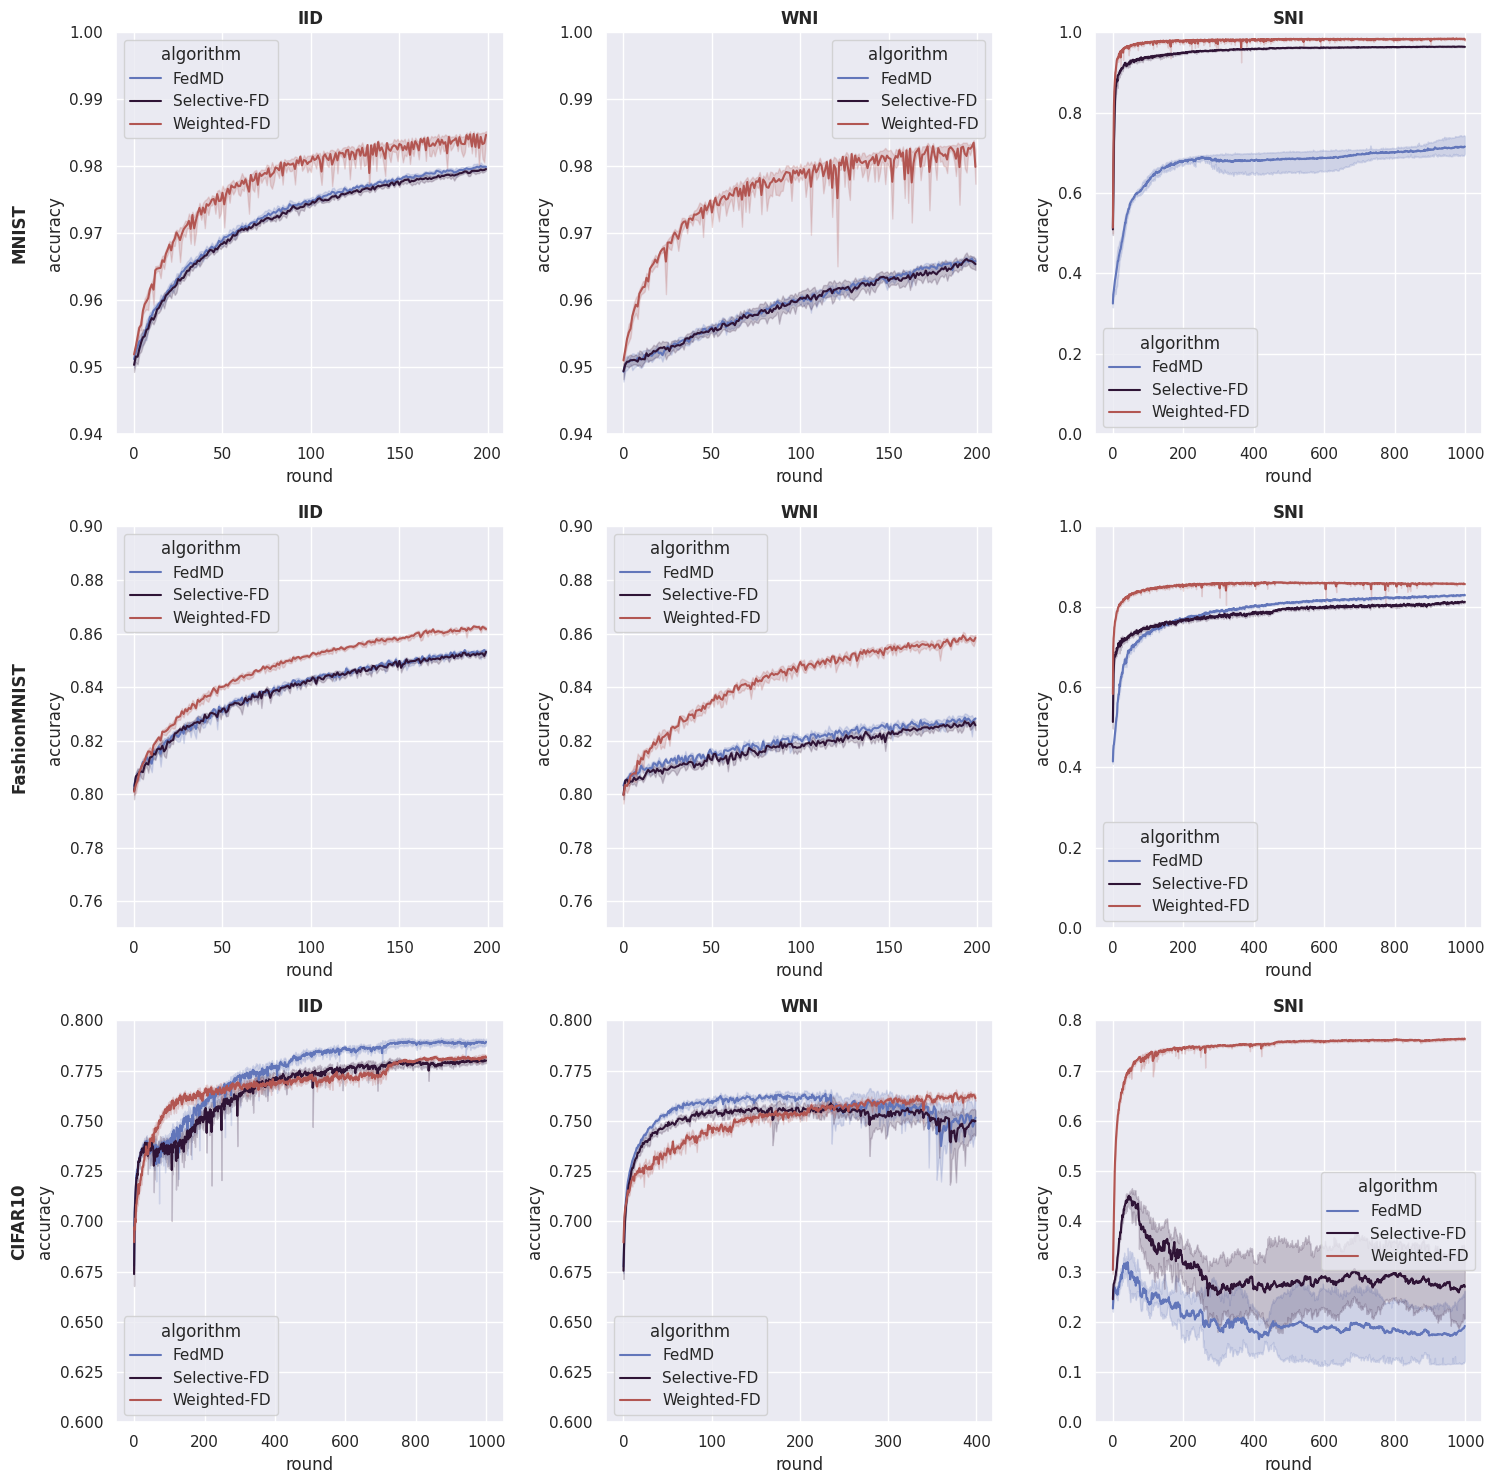

In [20]:
_, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

plot_convergence_ax(mnist_plot_df, lambda dataset_type : [0.94, 1.00] if dataset_type != 'hni' else [0., 1.00], ax=ax[0])
plot_convergence_ax(fashion_plot_df, lambda dataset_type : [0.75, 0.90] if dataset_type != 'hni' else [0., 1.00], ax=ax[1])
plot_convergence_ax(cifar10_plot_df, lambda dataset_type : [0.6, 0.8] if dataset_type != 'hni' else [0., 0.8], ax=ax[2])

ax[0,0].text(-0.275, 0.5, 'MNIST', rotation=90, fontsize=12, weight='bold', transform=ax[0,0].transAxes, verticalalignment='center')
ax[1,0].text(-0.275, 0.5, 'FashionMNIST', rotation=90, fontsize=12, weight='bold', transform=ax[1,0].transAxes, verticalalignment='center')
ax[2,0].text(-0.275, 0.5, 'CIFAR10', rotation=90, fontsize=12, weight='bold', transform=ax[2,0].transAxes, verticalalignment='center')

plt.tight_layout()
plt.savefig("../ignore/convergence.pdf", format='pdf')
plt.show()